# Interactive Contact Generation

Explore model predictions interactively. Provide a PDB structure,
examine its ground-truth contacts, then build prompts with custom
prefixes and see what the model generates.

In [1]:
# Config - change these
CHECKPOINT_PATH = "../../outputs/exp5.ethereal-galaxy-3/checkpoint-125500"
PDB_ID = "7VTY"  # change to any PDB ID
CONTACT_DISTANCE_CUTOFF = 4.0
DEVICE = "cuda"

In [2]:
# Setup: load structure, compute GT, load model
import tempfile, time
import numpy as np
import torch
from collections import Counter, defaultdict
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from scipy.spatial import KDTree
from transformers import LlamaForCausalLM
from experiments.exp5_contact_prediction.src.data import AMINO_ACIDS, VALID_ATOMS
from experiments.exp5_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

NONSTANDARD = {"MSE":"MET","CSE":"CYS","SEC":"CYS","HYP":"PRO","TPO":"THR","SEP":"SER","PTR":"TYR"}

# Parse structure
path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
atoms = pdbx.get_structure(pdbx.CIFFile.read(path).block, model=1)
chain = atoms[(atoms.chain_id==atoms.chain_id[0]) & filter_amino_acids(atoms) & (atoms.element!="H")]
unique_res = sorted(set(chain.res_id))
r2p = {rid:i+1 for i,rid in enumerate(unique_res)}
aa_set = set(AMINO_ACIDS)
sequence = [NONSTANDARD.get(str(chain[chain.res_id==rid].res_name[0]),
            str(chain[chain.res_id==rid].res_name[0])) for rid in unique_res]
seq_len = len(sequence)

# GT contacts
all_known = set()
for aa in VALID_ATOMS: all_known.update(VALID_ATOMS[aa])
tree = KDTree(chain.coord); pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)
best = {}
for i,j in pairs:
    pi,pj = r2p.get(chain.res_id[i]), r2p.get(chain.res_id[j])
    if pi is None or pj is None or abs(pi-pj)<2: continue
    ai,aj = str(chain.atom_name[i]), str(chain.atom_name[j])
    if ai not in all_known or aj not in all_known: continue
    if sequence[pi-1] not in VALID_ATOMS or ai not in VALID_ATOMS[sequence[pi-1]]: continue
    if sequence[pj-1] not in VALID_ATOMS or aj not in VALID_ATOMS[sequence[pj-1]]: continue
    d = float(np.linalg.norm(chain.coord[i]-chain.coord[j]))
    k = (min(pi,pj),max(pi,pj))
    if k not in best or d < best[k][0]:
        best[k] = (d, ai if pi<pj else aj, aj if pi<pj else ai)

gt_contacts = []  # (pos1, pos2, atom1, atom2, distance)
for (p1,p2), (d, a1, a2) in sorted(best.items(), key=lambda x: -abs(x[0][0]-x[0][1])):
    gt_contacts.append((p1, p2, a1, a2, d))
gt_pair_set = {(c[0],c[1]) for c in gt_contacts}

# Load model
tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(CHECKPOINT_PATH, torch_dtype=torch.bfloat16).to(DEVICE).eval()
end_token_id = tokenizer.convert_tokens_to_ids("<end>")

# Base prompt
seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
BASE_PROMPT = f"<random-3-bins> <begin_sequence> {seq_tokens} <begin_contacts>"

print(f"Protein {PDB_ID}: {seq_len} residues, {len(gt_contacts)} GT contact pairs")
print(f"  Short (6-12): {sum(1 for c in gt_contacts if 6<=abs(c[0]-c[1])<12)}")
print(f"  Medium (12-24): {sum(1 for c in gt_contacts if 12<=abs(c[0]-c[1])<24)}")
print(f"  Long (>=24): {sum(1 for c in gt_contacts if abs(c[0]-c[1])>=24)}")
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

/home/ubuntu/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 147/147 [00:00<00:00, 364.46it/s, Materializing param=model.norm.weight]                              


Protein 7VTY: 90 residues, 278 GT contact pairs
  Short (6-12): 13
  Medium (12-24): 9
  Long (>=24): 46
Model loaded: 984,528,896 parameters


In [3]:
# Show GT contacts
print(f"Ground truth contacts (sorted by decreasing separation):")
print(f"{'#':>4s} {'p1':>4s} {'p2':>4s} {'a1':>5s} {'a2':>5s} {'dist':>5s} {'sep':>4s}")
print("-" * 35)
for i, (p1, p2, a1, a2, d) in enumerate(gt_contacts):
    sep = abs(p1 - p2)
    if i < 30 or sep >= 24:
        print(f"{i:4d} {p1:>4d} {p2:>4d} {a1:>5s} {a2:>5s} {d:>5.1f} {sep:>4d}")
    elif i == 30:
        print(f"  ... (showing long-range only after first 30)")

Ground truth contacts (sorted by decreasing separation):
   #   p1   p2    a1    a2  dist  sep
-----------------------------------
   0    1   90     N    CB   3.4   89
   1    2   88    CG    CA   3.2   86
   2    3   88     N     O   3.4   85
   3    3   85    CB     O   3.9   82
   4    6   85    CB    CA   3.7   79
   5    6   84    CE     O   2.7   78
   6    7   85    CA   CD2   3.8   78
   7   10   84   ND2     O   3.5   74
   8   14   81   CG1   CD2   3.7   67
   9    7   69   CD1   CE2   3.7   62
  10   17   78     O   CE2   3.5   61
  11   19   78     N    OH   3.1   59
  12    4   63    CG   OD1   3.3   59
  13   22   78   OE1    OH   3.0   56
  14    4   59   NH2     O   2.9   55
  15   18   73   CD1   CD2   3.6   55
  16   14   69   CG2    CZ   4.0   55
  17   23   78   CD1   CE1   3.7   55
  18   22   76    CG    CD   3.8   54
  19    7   59   CD2    SD   3.6   52
  20   18   69   CD2    CZ   3.9   51
  21    8   59    CB    CE   3.5   51
  22   23   72   CG2    CB   3.7 

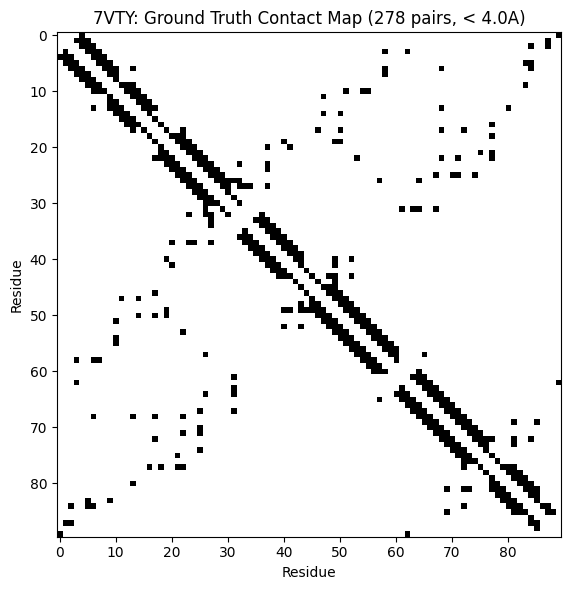

In [4]:
# GT contact map heatmap
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

gt_matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
for p1, p2, _, _, _ in gt_contacts:
    gt_matrix[p1-1, p2-1] = 1
    gt_matrix[p2-1, p1-1] = 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(gt_matrix, cmap=ListedColormap(["white", "black"]), vmin=0, vmax=1,
          origin="upper", aspect="equal")
ax.set_xlabel("Residue")
ax.set_ylabel("Residue")
ax.set_title(f"{PDB_ID}: Ground Truth Contact Map ({len(gt_contacts)} pairs, < {CONTACT_DISTANCE_CUTOFF}A)")
plt.tight_layout()
plt.show()

In [5]:
# Generation helper
def generate(prefix_contacts=None, n_rollouts=5, max_new_tokens=3440,
             do_sample=True, temperature=1.0):
    """Generate contacts from a prompt.
    
    Args:
        prefix_contacts: list of (p1, p2, a1, a2, bin) tuples to include as prefix,
                         or list of (p1, p2) pairs (will auto-fill atom names and bin from GT).
                         Or None for sequence-only.
        n_rollouts: number of rollouts to generate.
        max_new_tokens: max tokens to generate.
        do_sample: if True, sample; if False, greedy.
        temperature: sampling temperature.
    
    Returns:
        List of (contacts, valid_grammar, plddt) tuples.
    """
    # Build prompt
    prompt = BASE_PROMPT
    if prefix_contacts:
        prefix_toks = []
        for c in prefix_contacts:
            if len(c) == 2:
                # Just (p1, p2) - look up atoms from GT
                p1, p2 = min(c), max(c)
                if (p1, p2) in best:
                    d, a1, a2 = best[(p1, p2)]
                    prefix_toks.extend(["<non-correction>", f"<p{p1}>", f"<p{p2}>",
                                        f"<{a1}>", f"<{a2}>", "<bin_lt4>"])
                else:
                    print(f"  Warning: ({p1}, {p2}) not in GT, using backbone O-N")
                    prefix_toks.extend(["<non-correction>", f"<p{p1}>", f"<p{p2}>",
                                        "<O>", "<N>", "<bin_lt4>"])
            elif len(c) == 5:
                # (p1, p2, a1, a2, bin)
                p1, p2, a1, a2, b = c
                prefix_toks.extend(["<non-correction>", f"<p{p1}>", f"<p{p2}>",
                                    f"<{a1}>", f"<{a2}>", f"<{b}>"])
            elif len(c) == 6:
                # Full (is_corr, p1, p2, a1, a2, bin)
                is_corr, p1, p2, a1, a2, b = c
                corr = "<correction>" if is_corr else "<non-correction>"
                prefix_toks.extend([corr, f"<p{p1}>", f"<p{p2}>",
                                    f"<{a1}>", f"<{a2}>", f"<{b}>"])
        prompt = prompt + " " + " ".join(prefix_toks)
    
    prompt_len = len(prompt.split())
    print(f"Prompt: {prompt_len} tokens ({0 if not prefix_contacts else len(prefix_contacts)} prefix contacts)")
    
    results = []
    for r in range(n_rollouts):
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        t0 = time.time()
        with torch.no_grad():
            outputs = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=do_sample, temperature=temperature if do_sample else None,
                top_k=0 if do_sample else None,
                pad_token_id=tokenizer.pad_token_id, eos_token_id=end_token_id)
        elapsed = time.time() - t0
        gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
        contacts, valid, plddt = parse_generated_contacts(gen_text.split())
        results.append((contacts, valid, plddt))
        
        lt4 = {(min(c[1],c[2]),max(c[1],c[2])) for c in contacts if c[5]=="bin_lt4"}
        correct = len(lt4 & gt_pair_set)
        prec = correct/len(lt4) if lt4 else 0
        rec = correct/len(gt_pair_set) if gt_pair_set else 0
        bins = Counter(c[5] for c in contacts)
        print(f"  R{r}: {len(contacts)} contacts, P={prec:.1%} R={rec:.1%}, "
              f"bins={{lt4={bins.get('bin_lt4',0)}, 4-12={bins.get('bin_4_12',0)}, "
              f"gt12={bins.get('bin_gt12',0)}}}, {elapsed:.1f}s")
    
    return results

def show_results(results, title=""):
    """Show contact map and stats for generation results."""
    n = len(results)
    
    # Consensus frequency
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for contacts, valid, plddt in results:
        for c in contacts:
            if c[5] == "bin_lt4":
                p1, p2 = c[1], c[2]
                if 1<=p1<=seq_len and 1<=p2<=seq_len:
                    freq[p1-1, p2-1] += 1
                    freq[p2-1, p1-1] += 1
    freq /= n
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    
    # GT
    axes[0].imshow(gt_matrix, cmap=ListedColormap(["white", "black"]), vmin=0, vmax=1,
                   origin="upper", aspect="equal")
    axes[0].set_title(f"Ground Truth\n{len(gt_contacts)} pairs")
    axes[0].set_xlabel("Residue")
    axes[0].set_ylabel("Residue")
    
    # Consensus frequency
    im = axes[1].imshow(freq, cmap="hot_r", vmin=0, vmax=1, origin="upper", aspect="equal")
    axes[1].set_title(f"Consensus ({n} rollouts)")
    axes[1].set_xlabel("Residue")
    plt.colorbar(im, ax=axes[1], shrink=0.8)
    
    # Consensus > 0.3 binary
    pred_pairs = set()
    for i in range(seq_len):
        for j in range(i+1, seq_len):
            if freq[i,j] > 0.3:
                pred_pairs.add((i+1, j+1))
    correct = len(pred_pairs & gt_pair_set)
    prec = correct/len(pred_pairs) if pred_pairs else 0
    rec = correct/len(gt_pair_set) if gt_pair_set else 0
    
    pred_matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for p1, p2 in pred_pairs:
        pred_matrix[p1-1, p2-1] = 1
        pred_matrix[p2-1, p1-1] = 1
    axes[2].imshow(pred_matrix, cmap=ListedColormap(["white", "black"]), vmin=0, vmax=1,
                   origin="upper", aspect="equal")
    axes[2].set_title(f"Consensus > 30%\nP={prec:.0%} R={rec:.0%} ({correct}/{len(pred_pairs)})")
    axes[2].set_xlabel("Residue")
    
    fig.suptitle(title or f"{PDB_ID} Generation Results", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Range breakdown
    for rng, lo, hi in [("Short(6-12)", 6, 12), ("Med(12-24)", 12, 24), ("Long(>=24)", 24, 9999)]:
        p_r = {p for p in pred_pairs if lo <= abs(p[0]-p[1]) < hi}
        g_r = {p for p in gt_pair_set if lo <= abs(p[0]-p[1]) < hi}
        c_r = len(p_r & g_r)
        pr = c_r/len(p_r) if p_r else 0
        rc = c_r/len(g_r) if g_r else 0
        print(f"  {rng}: P={pr:.0%} R={rc:.0%} ({c_r}/{len(p_r)} correct, {len(g_r)} GT)")

print("Generation helpers ready.")
print(f"\nUsage:")
print(f"  results = generate()  # sequence only")
print(f"  results = generate(prefix_contacts=[(10, 50), (20, 80)])  # with GT contacts as prefix")
print(f"  results = generate(prefix_contacts=[(10, 50, 'O', 'N', 'bin_lt4')])  # custom atoms")
print(f"  show_results(results, 'My experiment')  # visualize")

Generation helpers ready.

Usage:
  results = generate()  # sequence only
  results = generate(prefix_contacts=[(10, 50), (20, 80)])  # with GT contacts as prefix
  results = generate(prefix_contacts=[(10, 50, 'O', 'N', 'bin_lt4')])  # custom atoms
  show_results(results, 'My experiment')  # visualize


Prompt: 93 tokens (0 prefix contacts)
  R0: 331 contacts, P=85.4% R=75.5%, bins={lt4=248, 4-12=53, gt12=30}, 30.5s
  R1: 363 contacts, P=73.1% R=71.2%, bins={lt4=271, 4-12=61, gt12=31}, 32.5s
  R2: 283 contacts, P=81.3% R=62.6%, bins={lt4=216, 4-12=44, gt12=23}, 25.3s
  R3: 312 contacts, P=81.4% R=69.1%, bins={lt4=236, 4-12=51, gt12=25}, 27.9s
  R4: 325 contacts, P=83.7% R=71.9%, bins={lt4=241, 4-12=55, gt12=29}, 29.1s


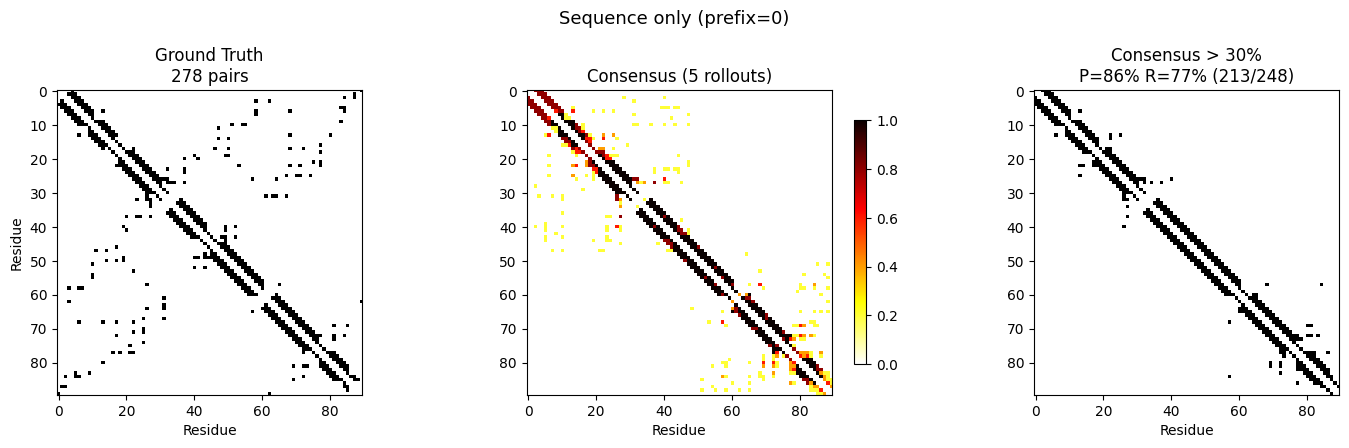

  Short(6-12): P=42% R=38% (5/12 correct, 13 GT)
  Med(12-24): P=33% R=11% (1/3 correct, 9 GT)
  Long(>=24): P=0% R=0% (0/1 correct, 46 GT)


In [6]:
# Baseline: sequence only
results_seq = generate(n_rollouts=5)
show_results(results_seq, "Sequence only (prefix=0)")

Longest-range contact: (1, 90), sep=89, atoms=N-CB, dist=3.4A
Prompt: 99 tokens (1 prefix contacts)
  R0: 337 contacts, P=79.4% R=72.3%, bins={lt4=253, 4-12=57, gt12=27}, 30.2s
  R1: 339 contacts, P=82.9% R=73.4%, bins={lt4=248, 4-12=62, gt12=29}, 30.3s
  R2: 309 contacts, P=84.7% R=69.8%, bins={lt4=229, 4-12=52, gt12=28}, 27.7s
  R3: 338 contacts, P=84.0% R=75.5%, bins={lt4=252, 4-12=58, gt12=28}, 30.3s
  R4: 338 contacts, P=78.7% R=73.0%, bins={lt4=258, 4-12=53, gt12=27}, 30.2s


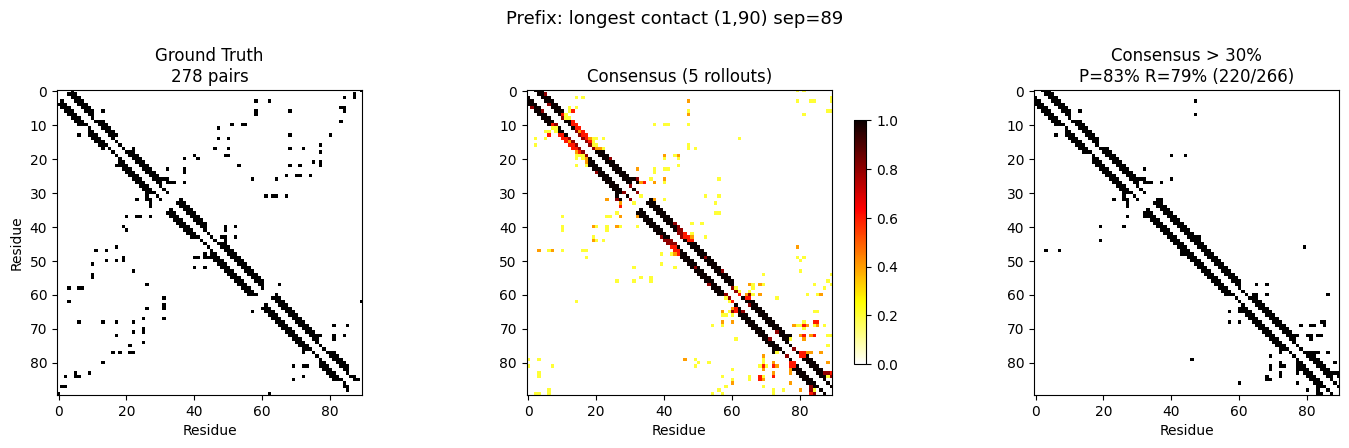

  Short(6-12): P=50% R=69% (9/18 correct, 13 GT)
  Med(12-24): P=50% R=44% (4/8 correct, 9 GT)
  Long(>=24): P=0% R=0% (0/5 correct, 46 GT)


In [7]:
# With longest-range GT contact as prefix
longest = gt_contacts[0]  # sorted by decreasing separation
print(f"Longest-range contact: ({longest[0]}, {longest[1]}), sep={abs(longest[0]-longest[1])}, "
      f"atoms={longest[2]}-{longest[3]}, dist={longest[4]:.1f}A")

results_longest = generate(prefix_contacts=[(longest[0], longest[1])], n_rollouts=5)
show_results(results_longest, f"Prefix: longest contact ({longest[0]},{longest[1]}) sep={abs(longest[0]-longest[1])}")

Prompt: 111 tokens (3 prefix contacts)
  R0: 293 contacts, P=67.6% R=51.1%, bins={lt4=212, 4-12=55, gt12=26}, 26.6s


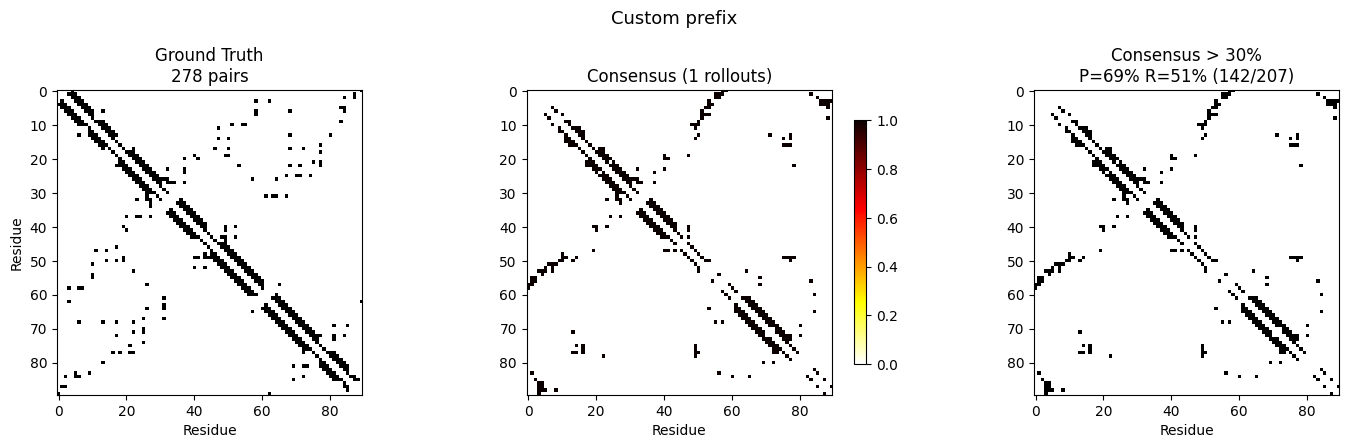

  Short(6-12): P=40% R=31% (4/10 correct, 13 GT)
  Med(12-24): P=43% R=33% (3/7 correct, 9 GT)
  Long(>=24): P=2% R=2% (1/51 correct, 46 GT)


In [10]:
results = generate(prefix_contacts=[(10, 50), (20, 80), (5, 90)], n_rollouts=1)
show_results(results, "Custom prefix")

In [23]:
import pandas as pd
pd.Series(sorted(list(zip(*np.where(gt_matrix))), key=lambda pair: -abs(pair[0] - pair[1]))).map(lambda p: sorted(p)).map(tuple).drop_duplicates().head(10)

0      (0, 89)
2      (1, 87)
4      (2, 87)
6      (2, 84)
8      (5, 84)
10     (5, 83)
11     (6, 84)
14     (9, 83)
16    (13, 80)
18     (6, 68)
dtype: object

Prompt: 105 tokens (2 prefix contacts)
  R0: 367 contacts, P=73.7% R=72.7%, bins={lt4=276, 4-12=62, gt12=29}, 33.4s


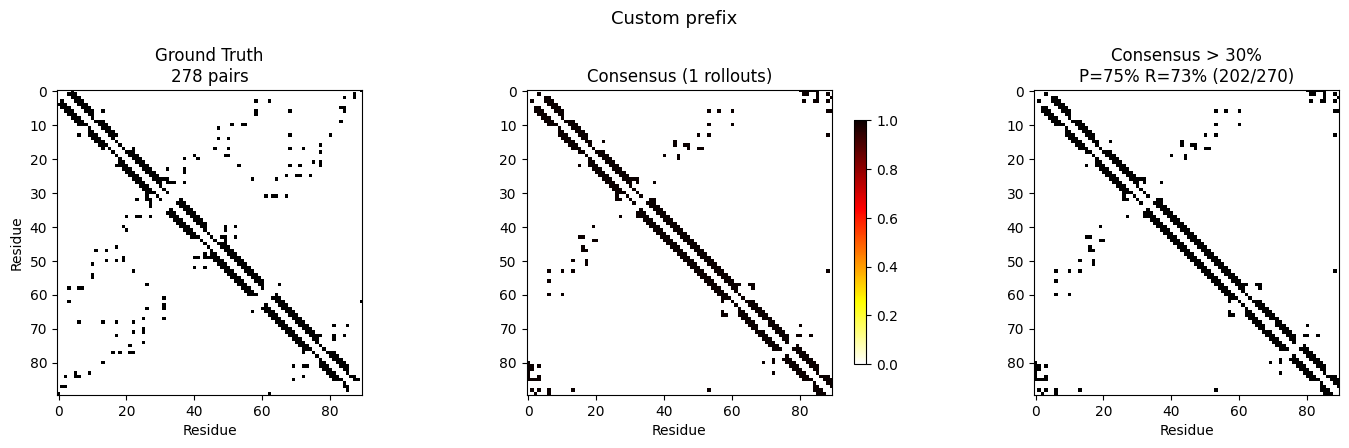

  Short(6-12): P=30% R=23% (3/10 correct, 13 GT)
  Med(12-24): P=100% R=11% (1/1 correct, 9 GT)
  Long(>=24): P=3% R=2% (1/36 correct, 46 GT)


In [26]:
results = generate(prefix_contacts=[(1, 90), (1, 87)], n_rollouts=1)
show_results(results, "Custom prefix")

In [8]:
# === ADD YOUR OWN EXPERIMENTS BELOW ===
# Examples:
#
# Provide specific contacts as prefix (just positions — atoms auto-filled from GT):
#   results = generate(prefix_contacts=[(10, 50), (20, 80), (5, 90)])
#   show_results(results, "Custom prefix")
#
# Provide contacts with specific atoms and bins:
#   results = generate(prefix_contacts=[(10, 50, 'O', 'N', 'bin_lt4')])
#
# Provide a false contact (not in GT) to see how the model handles it:
#   results = generate(prefix_contacts=[(1, 2, 'O', 'N', 'bin_gt12')])
#
# Multiple long-range contacts:
#   long_range = [(c[0], c[1]) for c in gt_contacts if abs(c[0]-c[1]) >= 24][:5]
#   results = generate(prefix_contacts=long_range)
#   show_results(results, "5 longest-range contacts as prefix")
#
# Greedy decoding:
#   results = generate(n_rollouts=1, do_sample=False)
#
# Lower temperature:
#   results = generate(temperature=0.5)